Saving goodreads_data.csv to goodreads_data.csv


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Total books loaded: 9923
0    unforgettable novel childhood sleepy southern ...
1    harry potter think ordinary boy rescued owl ta...
2    since immediate success pride prejudice remain...
3    discovered attic spent last year life anne fra...
4    librarian note alternate cover edition edition...
Name: clean_text, dtype: object


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/311 [00:00<?, ?it/s]

------------------------- EVALUATION RESULTS -------------------------
    Model  Precision@5  Precision@10  NDCG@10
0  TF-IDF        0.652         0.642    0.743
1   SBERT        0.748         0.728    0.801


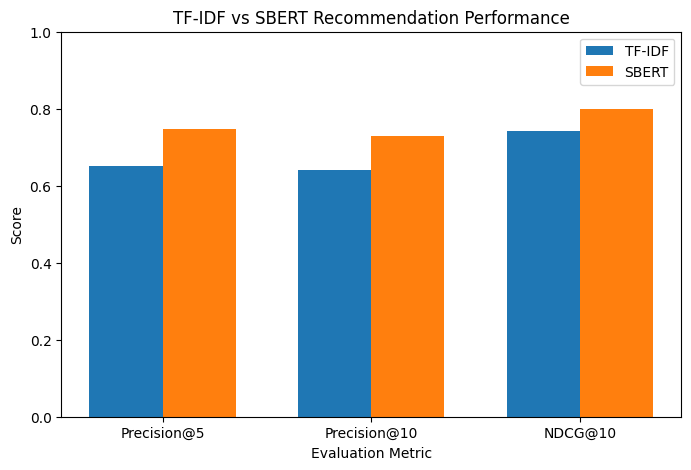


------------------------- TF-IDF Recommendations -------------------------
                                                 Book              Author  \
5168          Sourcery (Discworld, #5; Rincewind, #3)     Terry Pratchett   
164                      The Complete Sherlock Holmes  Arthur Conan Doyle   
7892  Wizard at Large (Magic Kingdom of Landover, #3)        Terry Brooks   
3733       The Golden Wizard (Scrolls of Zndaria, #1)         J.S. Jaeger   
2928          Fantastic Beasts and Where to Find Them      Newt Scamander   

                                                 Genres  
5168  ['Fantasy', 'Fiction', 'Humor', 'Comedy', 'Sci...  
164   ['Classics', 'Mystery', 'Fiction', 'Crime', 'S...  
7892  ['Fantasy', 'Fiction', 'Science Fiction Fantas...  
3733  ['Fantasy', 'Middle Grade', 'Childrens', 'Fict...  
2928  ['Fantasy', 'Fiction', 'Young Adult', 'Childre...  

------------------------- SBERT Recommendations -------------------------
                                      

In [ ]:
#Group Members:
#Shreya Ramsamooch:224107436
#Atiyah Khan:224018644
#Mikayla Pillay: 224044200

#1. INSTALL AND IMPORTS

#install all libraries needed for the project
!pip install pandas scikit-learn nltk sentence-transformers matplotlib

#upload the Goodreads dataset
from google.colab import files
uploaded = files.upload()

#importing general libraries
import pandas as pd
import numpy as np
import nltk
import re
import ast
import matplotlib.pyplot as plt

#nltk tools used for text cleaning
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

#sklearn tools for TF-IDF and similarity calculation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

#SBERT model import
from sentence_transformers import SentenceTransformer

#downloading nltk resources needed for preprocessing
nltk.download('stopwords')
nltk.download('wordnet')


#2. LOAD DATASET

#read the csv dataset
df = pd.read_csv("goodreads_data.csv", on_bad_lines='skip')

#remove spaces from column names just in case
df.columns = df.columns.str.strip()

#keep only rows where descriptions exist
df = df[df['Description'].notna()].reset_index(drop=True)

#convert genres from string format to python list
df['genres_list'] = df['Genres'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else []
)

#quick check of dataset size
print("Total books loaded:", len(df))


#3. TEXT FIELD

#using description column as the main text for recommendations
df['text'] = df['Description'].fillna('')


#4. PREPROCESSING (TF-IDF ONLY)

#initialise lemmatizer and stopword list
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

#function to clean text before TF-IDF
def preprocess(text):

    #convert text to lowercase
    text = text.lower()

    #remove numbers and special characters
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    #split sentence into words
    words = text.split()

    #remove stopwords and apply lemmatization
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    #join cleaned words back into sentence
    return " ".join(words)

#apply preprocessing to every book description
df['clean_text'] = df['text'].apply(preprocess)

#display sample cleaned text
print(df['clean_text'].head())


#5. TF-IDF MODEL

#create TF-IDF vectorizer using unigrams and bigrams
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

#convert cleaned text into numerical vectors
tfidf_matrix = vectorizer.fit_transform(df['clean_text'])

#function to recommend books using TF-IDF similarity
def recommend_tfidf(query, top_n=5):

    #check if user entered empty query
    if len(query.strip()) == 0:
        return "Please enter a valid query"

    #preprocess the query the same way as dataset text
    query = preprocess(query)

    #convert query into TF-IDF vector
    query_vec = vectorizer.transform([query])

    #calculate cosine similarity
    similarity = cosine_similarity(query_vec, tfidf_matrix).flatten()

    #get indices of most similar books
    indices = similarity.argsort()[-top_n:][::-1]

    #return top recommendations
    return df.iloc[indices][['Book', 'Author', 'Genres']]


#6. SBERT MODEL

#load pretrained Sentence-BERT model
model = SentenceTransformer('all-MiniLM-L6-v2')

#generate embeddings for all book descriptions
embeddings = model.encode(df['text'].tolist(), show_progress_bar=True)

#recommendation function using SBERT embeddings
def recommend_bert(query, top_n=5):

    #check for empty query
    if len(query.strip()) == 0:
        return "Please enter a valid query"

    #encode user query into embedding vector
    query_vec = model.encode([query])

    #calculate cosine similarity
    similarity = cosine_similarity(query_vec, embeddings).flatten()

    #get top matching books
    indices = similarity.argsort()[-top_n:][::-1]

    #return recommendations
    return df.iloc[indices][['Book', 'Author', 'Genres']]


#7. EVALUATION METRICS

#calculate how relevant a recommendation is based on genre overlap
def relevance_score(book_genres, query_genres):

    overlap = set(book_genres) & set(query_genres)

    return len(overlap) / len(set(query_genres)) if len(query_genres) > 0 else 0

#Precision@K measures how many recommended books are relevant
def precision_at_k(recommended_indices, query_genres, k=5):

    hits = 0

    for i in recommended_indices[:k]:

        #count recommendation as relevant if genres overlap
        if set(df.iloc[i]['genres_list']) & set(query_genres):
            hits += 1

    return hits / k

#calculate Discounted Cumulative Gain
def dcg_at_k(recommended_indices, query_genres, k=10):

    dcg = 0

    for rank, i in enumerate(recommended_indices[:k], start=1):

        rel = relevance_score(df.iloc[i]['genres_list'], query_genres)

        dcg += rel / np.log2(rank + 1)

    return dcg

#Normalised DCG gives score between 0 and 1
def ndcg_at_k(recommended_indices, query_genres, k=10):

    actual_rels = [
        relevance_score(df.iloc[i]['genres_list'], query_genres)
        for i in recommended_indices[:k]
    ]

    #ideal ranking sorted from highest relevance to lowest
    ideal_rels = sorted(actual_rels, reverse=True)

    dcg = sum(rel / np.log2(rank + 2) for rank, rel in enumerate(actual_rels))
    idcg = sum(rel / np.log2(rank + 2) for rank, rel in enumerate(ideal_rels))

    return dcg / idcg if idcg > 0 else 0


#8. RUN EXPERIMENTS

#setting random seed so results stay consistent
np.random.seed(42)

#randomly selecting 50 books for testing
sample = np.random.choice(
    df[df['genres_list'].apply(len) > 0].index,
    size=50,
    replace=False
)

#dictionary to store evaluation scores
results = {
    "TF-IDF_P@5": [],
    "TF-IDF_P@10": [],
    "TF-IDF_NDCG@10": [],
    "SBERT_P@5": [],
    "SBERT_P@10": [],
    "SBERT_NDCG@10": []
}

#run evaluation for each sampled book
for idx in sample:

    q_genres = df.iloc[idx]['genres_list']

    #TF-IDF similarity calculation
    tfidf_sim = cosine_similarity(
        vectorizer.transform([df.iloc[idx]['clean_text']]),
        tfidf_matrix
    ).flatten()

    #remove same book from recommendations
    tfidf_sim[idx] = -1

    #get top 10 recommendations
    tfidf_top10 = tfidf_sim.argsort()[-10:][::-1]

    #store TF-IDF scores
    results["TF-IDF_P@5"].append(precision_at_k(tfidf_top10, q_genres, k=5))
    results["TF-IDF_P@10"].append(precision_at_k(tfidf_top10, q_genres, k=10))
    results["TF-IDF_NDCG@10"].append(ndcg_at_k(tfidf_top10, q_genres, k=10))

    #SBERT similarity calculation
    bert_sim = cosine_similarity(
        embeddings[idx].reshape(1, -1),
        embeddings
    ).flatten()

    #remove same book from recommendations
    bert_sim[idx] = -1

    #get top 10 recommendations
    bert_top10 = bert_sim.argsort()[-10:][::-1]

    #store SBERT scores
    results["SBERT_P@5"].append(precision_at_k(bert_top10, q_genres, k=5))
    results["SBERT_P@10"].append(precision_at_k(bert_top10, q_genres, k=10))
    results["SBERT_NDCG@10"].append(ndcg_at_k(bert_top10, q_genres, k=10))


#9. RESULTS TABLE

#store average evaluation results in dataframe
results_table = pd.DataFrame({
    "Model": ["TF-IDF", "SBERT"],
    "Precision@5": [
        np.mean(results["TF-IDF_P@5"]),
        np.mean(results["SBERT_P@5"])
    ],
    "Precision@10": [
        np.mean(results["TF-IDF_P@10"]),
        np.mean(results["SBERT_P@10"])
    ],
    "NDCG@10": [
        np.mean(results["TF-IDF_NDCG@10"]),
        np.mean(results["SBERT_NDCG@10"])
    ]
})

#print final evaluation scores
print("------------------------- EVALUATION RESULTS -------------------------")
print(results_table.round(3))


#10. GRAPH

#list of evaluation metrics for plotting
metrics = ["Precision@5", "Precision@10", "NDCG@10"]

#positions for graph bars
x = np.arange(len(metrics))
width = 0.35

#create bar graph
plt.figure(figsize=(8, 5))

#TF-IDF bars
plt.bar(x - width/2, results_table.loc[0, metrics], width, label="TF-IDF")

#SBERT bars
plt.bar(x + width/2, results_table.loc[1, metrics], width, label="SBERT")

#graph labels and title
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.title("TF-IDF vs SBERT Recommendation Performance")

#show legend
plt.legend()

#display graph
plt.show()


#11. TEST QUERY

#example query for testing recommendations
query = "magic wizard school adventure"

#print TF-IDF recommendations
print("\n------------------------- TF-IDF Recommendations -------------------------")
print(recommend_tfidf(query))

#print SBERT recommendations
print("\n------------------------- SBERT Recommendations -------------------------")
print(recommend_bert(query))